# Tarea Semanal 4
## Teoría de Circuitos II
## Alumno
### Juan Manuel Miranda Del Valle
## Institución
### Universidad Tecnologica Nacional
## Profesores
### Mariano Llamedo Soria y César Fouco
## Consignas

<div align="center">
    <img src="1.png" width="1000">
</div>

#### Matriz MAI Red T
<div align="center">
    <img src="2.png" width="1000">
</div>

#### Matriz MAI BS170
<div align="center">
    <img src="3.png" width="1000">
</div>

### Punto 2 Item A
#### V23/V13

<div align="center">
    <img src="4.png" width="1000">
</div>

#### V21/V31

<div align="center">
    <img src="5.png" width="1000">
</div>

#### V12/V32

<div align="center">
    <img src="6.png" width="1000">
</div>

### Item B 
#### Modulo y fase de l;as 3 transferencias

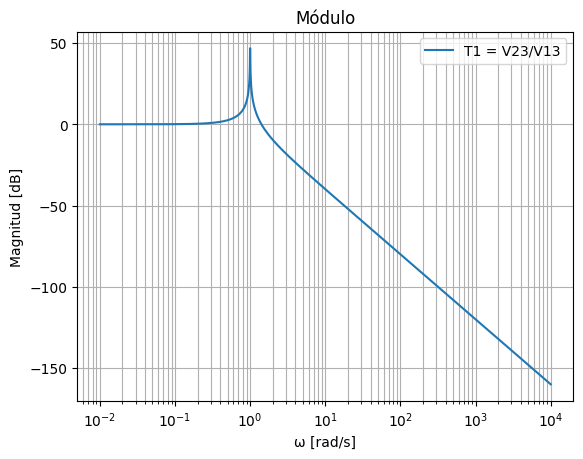

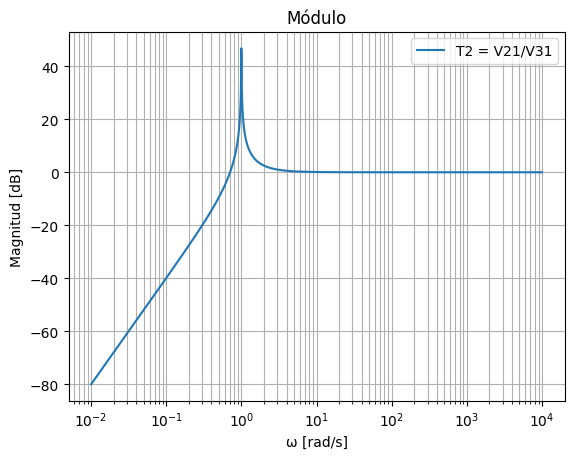

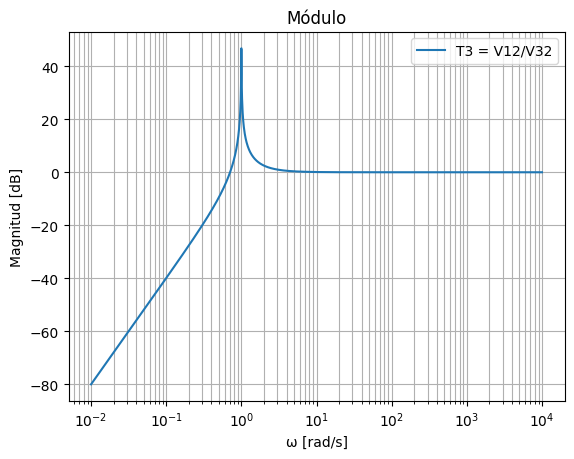

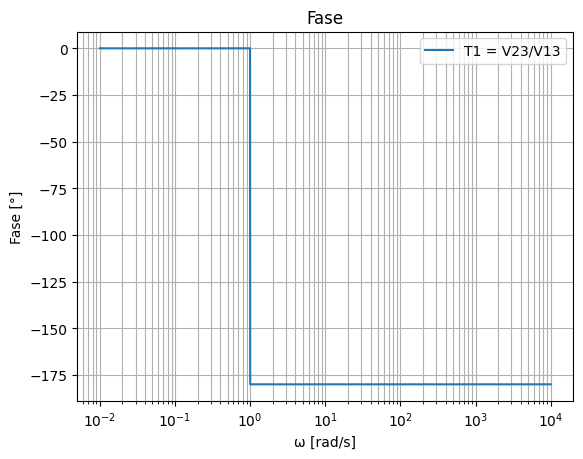

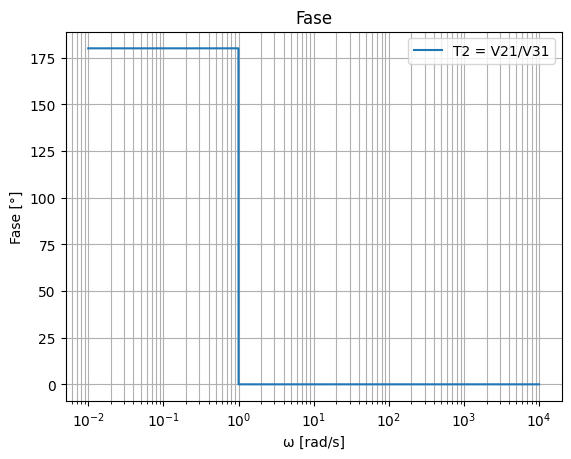

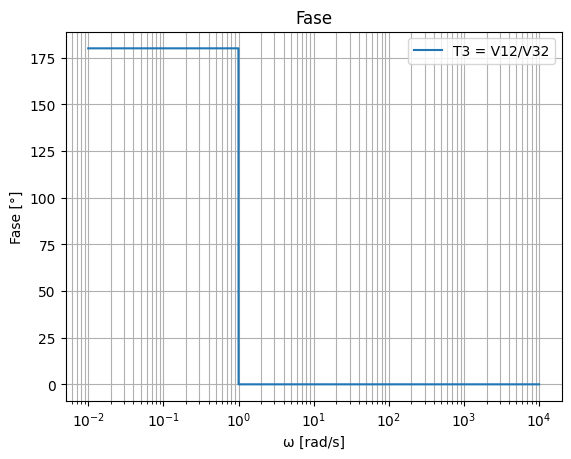

In [1]:
import numpy as np
from scipy import signal as sig
from matplotlib import pyplot as plt

# Valores
L = 1
C = 1
LC = L*C

# =========================================================
# TRANSFERENCIAS
# =========================================================

# T1 = V23/V13 = 1/(LC*s^2 + 1)
T1 = sig.TransferFunction(
    [1],
    [LC, 0, 1]
)

# T2 = V21/V31 = LC*s^2/(LC*s^2 + 1)
T2 = sig.TransferFunction(
    [LC, 0, 0],
    [LC, 0, 1]
)

# T3 = V12/V32 = LC*s^2/(LC*s^2 + 1)
T3 = sig.TransferFunction(
    [LC, 0, 0],
    [LC, 0, 1]
)

# =========================================================
# FRECUENCIAS
# Evito el 0
# =========================================================

w0 = 1 / np.sqrt(LC)

w1 = np.logspace(-2, np.log10(w0)-0.001, 1000)
w2 = np.logspace(np.log10(w0)+0.001, 4, 1000)

w = np.concatenate((w1, w2))

# =========================================================
# RESPUESTA EN FRECUENCIA
# =========================================================

w, H1 = sig.freqresp(T1, w)
_, H2 = sig.freqresp(T2, w)
_, H3 = sig.freqresp(T3, w)

# =========================================================
# MODULO
# =========================================================

plt.figure()

plt.semilogx(w, 20*np.log10(np.abs(H1)), label="T1 = V23/V13")

plt.title("Módulo")
plt.xlabel("ω [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, which="both")
plt.legend()

plt.figure()
plt.semilogx(w, 20*np.log10(np.abs(H2)), label="T2 = V21/V31")


plt.title("Módulo")
plt.xlabel("ω [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, which="both")
plt.legend()

plt.figure()
plt.semilogx(w, 20*np.log10(np.abs(H3)), label="T3 = V12/V32")

plt.title("Módulo")
plt.xlabel("ω [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, which="both")
plt.legend()
# =========================================================
# FASE
# =========================================================

plt.figure()

plt.semilogx(w, np.angle(H1, deg=True), label="T1 = V23/V13")

plt.title("Fase")
plt.xlabel("ω [rad/s]")
plt.ylabel("Fase [°]")
plt.grid(True, which="both")
plt.legend()

plt.figure()

plt.semilogx(w, np.angle(H2, deg=True), label="T2 = V21/V31")

plt.title("Fase")
plt.xlabel("ω [rad/s]")
plt.ylabel("Fase [°]")
plt.grid(True, which="both")
plt.legend()

plt.figure()

plt.semilogx(w, np.angle(H3, deg=True), label="T3 = V12/V32")

plt.title("Fase")
plt.xlabel("ω [rad/s]")
plt.ylabel("Fase [°]")
plt.grid(True, which="both")
plt.legend()


#### Combinaciones de las transferencias para evaluar complementariedad

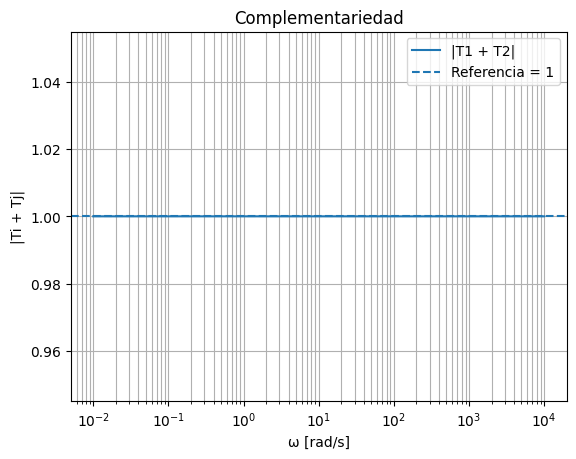

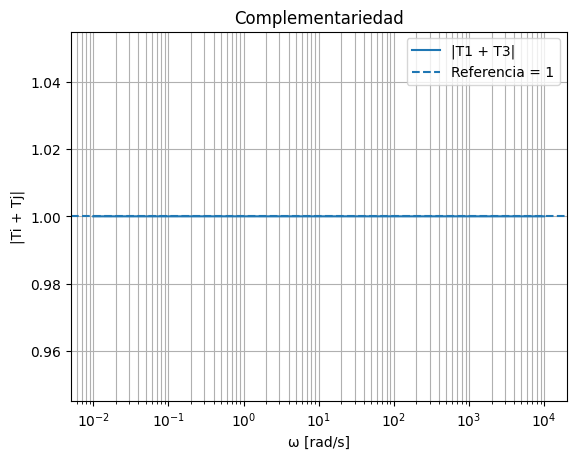

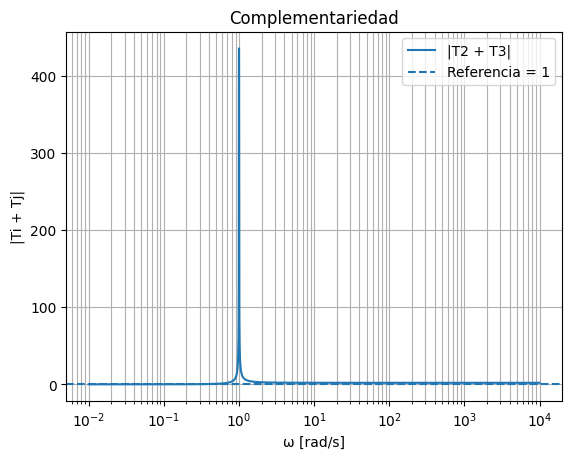

In [2]:
suma12 = H1 + H2
suma13 = H1 + H3
suma23 = H2 + H3

## H1+H2
plt.figure()

plt.semilogx(w, np.abs(suma12), label="|T1 + T2|")

plt.axhline(1, linestyle="--", label="Referencia = 1")

plt.title("Complementariedad")
plt.xlabel("ω [rad/s]")
plt.ylabel("|Ti + Tj|")
plt.grid(True, which="both")
plt.legend()

## H1+H3
plt.figure()

plt.semilogx(w, np.abs(suma13), label="|T1 + T3|")

plt.axhline(1, linestyle="--", label="Referencia = 1")

plt.title("Complementariedad")
plt.xlabel("ω [rad/s]")
plt.ylabel("|Ti + Tj|")
plt.grid(True, which="both")
plt.legend()

## H3+H2
plt.figure()

plt.semilogx(w, np.abs(suma23), label="|T2 + T3|")

plt.axhline(1, linestyle="--", label="Referencia = 1")

plt.title("Complementariedad")
plt.xlabel("ω [rad/s]")
plt.ylabel("|Ti + Tj|")
plt.grid(True, which="both")
plt.legend()


#### Tanto para T1+T2 como para T1+T3 se comprueba que hay complementariedad


### Ejercicio 3 Item A
#### Source Comun
<div align="center">
    <img src="7.png" width="1000">
</div>


#### Drain Comun
<div align="center">
    <img src="8.png" width="1000">
</div>

### Item b Obvencion de los parametros ABCD

<div align="center">
    <img src="9.png" width="1000">
</div>

### Bonus 1

In [2]:
import sympy as sp

from pytc2.cuadripolos import calc_MAI_impedance_ij, calc_MAI_vtransf_ij_mn, calc_MAI_ztransf_ij_mn
from pytc2.general import print_latex


# T puenteado cargado: red de R constante
# explicación:
'''    
+ Numeramos los polos de 0 a n=3

        1-------1/SL----4---1/Sl---2
                    |       
                   SC       
                    |       
                    3
    
'''    

S , C, L = sp.symbols('S C L', real=True, positive=True)

# Armo la MAI
# Numero de 0 a 3 en el programa pero en el resultado uso numeracion de 1 a 4

#               Nodos: 0        1        2        3
Ymai = sp.Matrix([  
                    [ 1/(S*L),   0,      0,     -1/(S*L)],
                    [ 0,      1/(S*L),    0,    -1/(S*L)],
                    [ 0,        0,        S*C,     -S*C],
                    [ -1/(S*L),   -1/(S*L),     -S*C,      2/(S*L)+S*C ]
                 ])

## Calculo de V13/V23
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 0, 2, 1, 2, verbose=False)
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(1, 3, 2, 3) +  sp.latex(Vmai))
## Calculo de V21/V31
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 1, 0, 2, 0, verbose=False)
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(2, 1, 3, 1) +  sp.latex(Vmai))
## Calculo de V12/V32
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 0, 1, 2, 1, verbose=False)
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(1, 2, 3, 2) +  sp.latex(Vmai))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Bonus 2 Simulacion Circuital del BS170
#### Dispuse el siguiente circuito
<div align="center">
    <img src="10.png" width="1000">
</div>

 #### Y11

 <div align="center">
    <img src="11.png" width="1000">
</div>

 #### Y12

 <div align="center">
    <img src="12.png" width="1000">
</div>

 #### Y21

 <div align="center">
    <img src="13.png" width="1000">
</div>

 #### Y22

 <div align="center">
    <img src="14.png" width="1000">
</div>